# Max-Cut Algorithm
## Librerías

In [1]:
#Libraries
import dimod
import networkx as nx
import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler
import random
import numpy as np
from itertools import combinations
import itertools
import pickle
from IPython.display import Image




## Funcion que genere un grafo aleatorio ponderado de tamaño n

In [2]:
def grafo_aleat_plot(n, p, seed=None):  
    # n: tamaño de mi grafo, numero de nodos
    # p entre 0 y 1: prob de generar una arista entre 2 nodos
    
    rng = random.Random(seed)
    
    # grafo aleatorio
    G = nx.erdos_renyi_graph(n, p,seed=seed)
    
    print("Nodos:", G.nodes())
        
    # grafo ponderado
    # Agregar pesos aleatorios en el rango [-1, 1] ==  [peso_min, peso_max]
    for (u, v) in G.edges(): 
        G[u][v]['weight'] = rng.uniform(-1, 1)
        # G.edges devuelve una lista de todas las airstas (u,v)
        # G[u][v] te da acceso al diccionario de atributos de la arista que conecta los nodos u y v.
        # G[u][v]['weight'] modificamos el peso de cada arista con un valor aleatorio entre -1 y 1
        
    print("Aristas con pesos:")
    for u, v, data in G.edges(data=True):
        print(f"({u}, {v}) -> peso = {data['weight']:.2f}")         
       
    # Pesos y grosor de aristas
    weights = nx.get_edge_attributes(G, 'weight')
    widths = [1.2 + 2.0 * abs(w) for w in weights.values()]
    
    #  pos = nx.circular_layout(G)
    pos = nx.spring_layout(G, seed=seed, k=1.5/np.sqrt(n))
    
    
    # --- Dibujo elegante ---
    plt.figure(figsize=(7, 6))
    plt.title(f"Random Weighted Graph ({n} nodes)", fontsize=13, fontweight='semibold')

    # Aristas finas, gris oscuro
    nx.draw_networkx_edges(G, pos, width=1.0, edge_color="#555", alpha=0.75)

    # Nodos azul-verdoso profesional
    nx.draw_networkx_nodes(G, pos,
                           node_size=650,
                           node_color="#6baed6",    # azul medio elegante
                           edgecolors="#08306b",    # borde azul oscuro
                           linewidths=1.0)

    # Etiquetas de nodos
    nx.draw_networkx_labels(G, pos,
                            font_size=9.5,
                            font_color="#0f172a",
                            font_weight="semibold")

    # Etiquetas de pesos de aristas (opcionales, se pueden comentar)
    nx.draw_networkx_edge_labels(G, pos,
                                 edge_labels={k: f"{v:.2f}" for k, v in weights.items()},
                                 font_size=8,
                                 font_color="#444",
                                 rotate=False)
   
    # título de mi grafo
    plt.title(f"Random Graph with {n} nodes, Before Max-Cut Algorithm")
    plt.axis("off") # quita el recuadro que engloba todo el plot
    plt.savefig('mi_grafo.png', dpi=300)
    plt.show()
    
    return G

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Aristas con pesos:
(0, 2) -> peso = 0.28
(0, 3) -> peso = -0.95
(0, 4) -> peso = -0.45
(0, 8) -> peso = -0.55
(0, 10) -> peso = 0.47
(0, 11) -> peso = 0.35
(0, 13) -> peso = 0.78
(0, 14) -> peso = -0.83
(1, 4) -> peso = -0.16
(1, 7) -> peso = -0.94
(1, 11) -> peso = -0.56
(1, 14) -> peso = 0.01
(2, 3) -> peso = -0.95
(3, 6) -> peso = -0.60
(3, 7) -> peso = 0.30
(3, 8) -> peso = 0.09
(3, 9) -> peso = -0.56
(3, 10) -> peso = 0.18
(3, 11) -> peso = 0.62
(3, 12) -> peso = -0.99
(4, 6) -> peso = 0.61
(4, 7) -> peso = 0.40
(4, 11) -> peso = -0.32
(4, 13) -> peso = -0.69
(5, 12) -> peso = 0.91
(5, 13) -> peso = -0.33
(6, 7) -> peso = -0.81
(6, 8) -> peso = -0.81
(7, 9) -> peso = 0.69
(7, 10) -> peso = 0.21
(7, 12) -> peso = 0.61
(8, 10) -> peso = 0.46
(8, 13) -> peso = 0.07
(8, 14) -> peso = 0.95
(9, 10) -> peso = -0.24
(9, 14) -> peso = 0.10
(11, 13) -> peso = 0.66
(13, 14) -> peso = 0.24


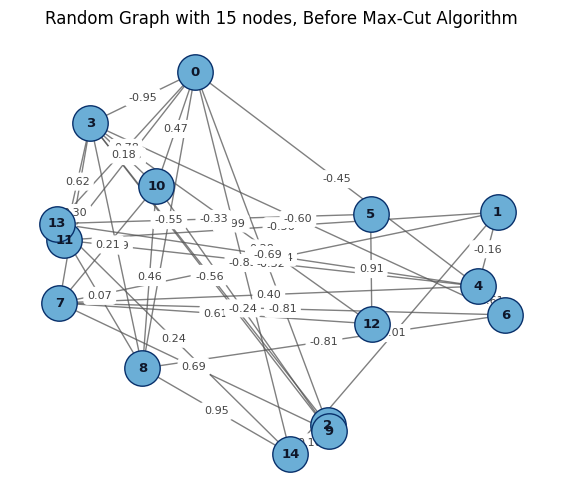

In [3]:
G=grafo_aleat_plot(15,0.3,seed=42)

##  Seleccionar aleatoriamente un conjunto de pares must-link y cannot-link

In [6]:
def must_link(G, cantidad, seed=None):
    # cantidad: numero de pares must-link a seleccionar
    # 
    rng = random.Random(seed) # objeto generador de numeros aleatorios
    aristas = list(G.edges()) # todas las aristas de nuestro grafo

    if cantidad > len(aristas): 
        raise ValueError(f"El grafo solo tiene {len(aristas)} aristas, no se pueden generar {cantidad} must-links.")
        # interrumple la ejecución e informa del problema (se quiere generar mas cantidad de pares que aristas hay en el grafo)
        
    seleccion = rng.sample(aristas, cantidad)
        # selecciona el numero 'cantidad' de elementos distintos sin repetir de las aristas
    return [tuple(sorted(p)) for p in seleccion]
        # Devuelve la lista de pares seleccionados, ordenando cada par. [pares de nodos q deben estar juntos]
        # for p in seleccion recorre cada arista elegida.
        # tuple(sorted(p)) ordena los nodos dentro del par (por ejemplo, convierte (3, 1) en (1, 3)).
            # Esto evita tener duplicados como (1,3) y (3,1) si luego comparas pares.

In [7]:
def cannot_link(G, cantidad, seed=None):
    # cantidad: numero de pares must-link a seleccionar
    
    rng = random.Random(seed) # objeto generador de numeros aleatorios
    todos_pares = list(combinations(G.nodes(), 2))
    aristas = {tuple(sorted(e)) for e in G.edges()}
    no_aristas = list(set(todos_pares) - aristas)

    if cantidad > len(no_aristas):
        raise ValueError(f"No hay suficientes pares no conectados para generar {cantidad} cannot-links.")

    seleccion = rng.sample(no_aristas, cantidad)
    return [tuple(sorted(p)) for p in seleccion]

## Construir el diccionario QUBO con las contribuciones del corte ponderado, del balanceo, y de las restricciones.

### QUBO funcion minima energia

In [8]:
def QUBO(G):
    Q = {}

    for i,j, data in G.edges(data=True):
        w = data['weight']  # peso de la arista (i,j)
        if i > j:
            i, j = j, i
        Q[(i,j)] = Q.get((i,j), 0.0) + 2.0 * w
        Q[(i,i)] = Q.get((i,i), 0.0) - 1.0 * w
        Q[(j,j)] = Q.get((j,j), 0.0) - 1.0 * w
    return Q

### QUBO contribución de balanceo

In [9]:
def balanceo(G,A):
    Qb = {}
    V = G.number_of_nodes() 
    
    for i in G.nodes:
        for j in G.nodes:
            if i < j:
                  Qb[(i,j)] = Qb.get((i,j), 0.0) + 2.0 * A
        Qb[(i,i)] = Qb.get((i,i), 0.0) + (1.0 - V) * A
   
    return Qb

### QUBO contribución must-link

In [10]:
def must(G,B,cantidad=None,seed=None):
    Qm = {}
 
    if cantidad is None:
        cantidad = max(1, G.number_of_edges() // 5)  # valor automático
    # Así, si lo quieres forzar, puedes pasar cantidad=5; pero si no, la función decide sola en base al tamaño del grafo.
    # como una fracción (por ejemplo, el 20%) del total de aristas para usar como restricciones
    
    must_pairs=must_link(G,cantidad,seed)    
    print("Pares must-link seleccionados:", must_pairs)
    
    for i,j in must_pairs:
        if i > j:
            i, j = j, i
        Qm[(i,j)] = Qm.get((i,j), 0.0) - 2.0 * B
        Qm[(i,i)] = Qm.get((i,i), 0.0) + 1.0 * B
        Qm[(j,j)] = Qm.get((j,j), 0.0) + 1.0 * B
    return Qm, must_pairs

### QUBO contribución cannot-link

In [11]:
def cannot(G,C,cantidad=None,seed=None):
    Qc = {}

    if cantidad is None:
        cantidad = max(1, G.number_of_edges() // 5)  # valor automático

    cannot_pairs=cannot_link(G,cantidad,seed)
        
    print("Pares cannot-link seleccionados:", cannot_pairs)    
    
    for i,j in cannot_pairs:
        if i > j:
            i, j = j, i
        Qc[(i,j)] = Qc.get((i,j), 0.0) + 2.0 * C
        Qc[(i,i)] = Qc.get((i,i), 0.0) - 1.0 * C
        Qc[(j,j)] = Qc.get((j,j), 0.0) - 1.0 * C
    return Qc, cannot_pairs

### Juntamos todas las contribuciones a una misma funcion QUBO_total

In [12]:
# Combinamos los QUBOS sumando coeficiente a coeficiente
def combinar_QUBOs(*Qlist):
    # * delante del nombre de un parámetro significa ''recibir un número variable de argumentos''
    """
    Combina varios diccionarios QUBO sumando sus coeficientes.
    Qlist: Q1, Q2, Q3, ...
    """
    Q_total = {}
    for Q in Qlist:
        for key, val in Q.items():
            Q_total[key] = Q_total.get(key, 0.0) + val
    return Q_total

In [37]:
# Función final: construir todo junto
def QUBO_total(G, A=1.0, B=2.0, C=1.0,seed=None):
    """
    Construye el QUBO completo con:
    - Max-Cut (Q)
    - Balanceo (Qb)
    - Must-Link (Qm)
    - Cannot-Link (Qc)
    """

    Q = QUBO(G)
    Qb = balanceo(G, A)
    Qm, must_pairs = must(G, B)
    Qc, cannot_pairs = cannot(G, C)

    Q_total = combinar_QUBOs(Q, Qb, Qm, Qc)
    return Q_total, must_pairs, cannot_pairs


In [38]:
# crear el modelo bqm, para que lo pueda entender DWave
Q_total, must_pairs, cannot_pairs = QUBO_total(G, A=0.5, B=2.0, C=2.0,seed=42)


bqm = dimod.BinaryQuadraticModel.from_qubo(Q_total)

Pares must-link seleccionados: [(2, 3), (0, 2), (13, 14), (3, 6), (7, 9), (11, 13), (0, 10)]
Pares cannot-link seleccionados: [(4, 12), (11, 14), (0, 12), (3, 13), (4, 10), (0, 9), (1, 10)]


## Resolver el QUBO mediante el método de fuerza bruta (búsqueda exhaustiva) y utilizando la librería SimulatedAnnealingSampler() del D-Wave SDK.

### Método fuerza bruta (búsqueda exhaustiva)

In [39]:
# el qubo define la energia total que queremos minimizar
# esta funcion calcula el valor de la energia para una configuracion concreta de bits x

def energia_qubo(x, Q):
    if isinstance(x, dict):
        asignacion = x
    else:
        asignacion = {i: bit for i, bit in enumerate(x)}
    return float(sum(val * asignacion[i] * asignacion[j]
                     for (i, j), val in Q.items()))

In [40]:

def fuerza_bruta_QUBO(Q):
    """Resuelve el QUBO probando todas las combinaciones binarias."""
    n = max(max(i, j) for (i, j) in Q.keys()) + 1 
    # recorre todas las claves (i,j) del diccionario Q y busca el índice más grande (max(i,j)).
    # le suma +1 pq los nodos están indexados desde 0.
    
    mejores_x = None # guarda la configuración de bits correspondientes
    mejor_E = float("inf") # guarda la menor energía encontrada (empieza en infinito)

    for x in itertools.product([0, 1], repeat=n):
        # genera todas las combinaciones binarias de longitud n: son 2^n combinaciones, 2^n x posibles.
        E = energia_qubo(x, Q)  # calcula E con la funcion anterior
        if E < mejor_E:
            mejor_E = E
            mejores_x = x

    return mejores_x, mejor_E

In [41]:
# Supongamos que ya tienes tu QUBO como diccionario
x_opt, E_opt = fuerza_bruta_QUBO(Q_total)
print("Mejor solución:", x_opt)
print("Energía mínima:", E_opt)

Mejor solución: (0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0)
Energía mínima: -40.82492511452763


### Utilizando SimulatedAnnealingSampler() de D-Wave

In [42]:
# ---- 3) Solve with simulated annealing --------------------------------------
sampler = SimulatedAnnealingSampler()  # metodo de resolucion clasico q imita un annealear cuantico pero en software
sampleset = sampler.sample(bqm, num_reads=500, beta_range=[0.1, 4.0], seed=123)
# el algoritmo hace el ''annealing'' muchas veces, 500, para buscar la mejor solucion. Devuelve un objeto 'SampleSet' con todas las soluciones encontradas
# cada sol es un vector binario x, con su energia E(x) y su frecuencia (cuantas veces apareció)
# beta_range define la velocidad de enfriamiento: empieza caliente explora mas y termina frio, refinando.
# seed es la semilla aleatoria, que asegura que los resultados sean reproducibles.


best = sampleset.first # devuelve la mejor muestra, la de menor energia
x = best.sample # es un diccionario {i:0/1,...} con la asignación de los nodos
energy = best.energy # la energia minima encontrada
# Emin=-cut(x) -> el menor valor de energia corresponde al mayor corte

print(sampleset) # como en mi ejemplo los pesos son iguales todas las energias dan lo mismo: -4
print(energy)

     0  1  2  3  4  5  6  7  8  9 10 11 12 13 14     energy num_oc.
3    1  0  1  1  0  0  1  0  0  0  1  0  1  0  1 -40.824925       1
4    0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
5    0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
7    0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
18   0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
22   0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
24   0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
25   0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
26   1  0  1  1  0  0  1  0  0  0  1  0  1  0  1 -40.824925       1
27   1  0  1  1  0  0  1  0  0  0  1  0  1  0  1 -40.824925       1
30   1  0  1  1  0  0  1  0  0  0  1  0  1  0  1 -40.824925       1
32   0  1  0  0  1  1  0  1  1  1  0  1  0  1  0 -40.824925       1
35   1  0  1  1  0  0  1  0  0  0  1  0  1  0  1 -40.824925       1
36   1  0  1  1  0  0  1  0  0  0  1  0  1  0  1

In [43]:
# ---- 4) Evaluate cut size ----------------------------------------------------
# evaluar el tamaño del corte. cuenta cuantas aristas se cortan: cuantas conectan nodos en lados opuestos.
def cut_value(assign, edge_list):
    return sum(assign[i] != assign[j] for i, j in edge_list)
    # recorre todas las aristas (i,j) del grafo.
    # para cada arista, evalúa la condición assign[i] != assign[j]: true(1) si los nodos están en distintos grupos -> la arista está cortada 
    # o false (0) si están en el mismo grupo -> no está cortada
    # en resumen: cuenta cuántias aristas conectan nodos en grupos opuestos.
    
# assign={0: 0, 1:1, 2:0, 3:1}, el nodo 0 está en el grupo A, el 1 en B, el 2 en A y el 3 en B.
# assign = x = best.sample = {1,0,1,0}
# edge_list = edges = es la lista de aristas del grafo [(0, 1), (1, 2), (2, 3), (0, 3)]

cut = cut_value(x, G.edges)
print(cut)

20


## Mostrar en ambos casos:
 - Energía mínima encontrada.
 - Tamaños de las particiones.
 - Peso total del corte.
 - Número de violaciones de restricciones.


In [44]:
# cosas globales de ambas

print("Pares must-link seleccionados:", must_pairs)
print("Pares cannot-link seleccionados:", cannot_pairs)

Pares must-link seleccionados: [(2, 3), (0, 2), (13, 14), (3, 6), (7, 9), (11, 13), (0, 10)]
Pares cannot-link seleccionados: [(4, 12), (11, 14), (0, 12), (3, 13), (4, 10), (0, 9), (1, 10)]


### Resultados con el método de fuerza bruta

In [45]:
print("Resultados con el método de fuerza bruta:")

x_opt, E_opt = fuerza_bruta_QUBO(Q_total)

print(" Mejor solución:", ''.join(str(x_opt[i]) for i in sorted(G.nodes)))
print(" Energía mínima:", E_opt)

grupo_A = [i for i, bit in enumerate(x_opt) if bit == 0]
grupo_B = [i for i, bit in enumerate(x_opt) if bit == 1]

print(" Los tamaños de las particiones son:")
print(f" Partición A ({len(grupo_A)} nodos):", grupo_A)
print(f" Partición B ({len(grupo_B)} nodos):", grupo_B)

tamaño_corte=sum(1 for u, v in G.edges if x_opt[u] != x_opt[v])
print(" Tamaño del corte:", tamaño_corte, "de", len(G.edges))
peso_corte = sum(
    data['weight']
    for u, v, data in G.edges(data=True)
    if x_opt[u] != x_opt[v]
)
print(" Peso total del corte:", peso_corte)

violaciones_must = sum(x_opt[i] != x_opt[j] for i, j in must_pairs)
violaciones_cannot = sum(x_opt[i] == x_opt[j] for i, j in cannot_pairs)

violaciones_total = violaciones_must + violaciones_cannot

print("\nViolaciones de restricciones:")
print(f" Must-link: {violaciones_must}")
print(f" Cannot-link: {violaciones_cannot}")
print(f" TOTAL: {violaciones_total}")


Resultados con el método de fuerza bruta:
 Mejor solución: 010011011101010
 Energía mínima: -40.82492511452763
 Los tamaños de las particiones son:
 Partición A (7 nodos): [0, 2, 3, 6, 10, 12, 14]
 Partición B (8 nodos): [1, 4, 5, 7, 8, 9, 11, 13]
 Tamaño del corte: 20 de 38
 Peso total del corte: 2.8249251145276233

Violaciones de restricciones:
 Must-link: 1
 Cannot-link: 1
 TOTAL: 2


### Resultados con SimulatedAnnealingSampler()

In [46]:
# ---- 5) Display results -------------------------------------------------------
print("Resultados con SimulatedAnnealingSampler() de D-Wave SDK:")

print(" Mejor solución:", ''.join(str(x[i]) for i in sorted(G.nodes)))
print(" Energia minima:", energy)
print(" Tamaño del corte:", cut, "de", len(G.edges))

cut_weight_sa = sum(G[u][v]['weight']
                    for u, v in G.edges if x[u] != x[v])
print(" Peso total del corte:", cut_weight_sa)

print(" Los tamaños de las particiones son:")
print(f" Partición A ({len([i for i in sorted(G.nodes) if x[i] == 0])} nodos):", [i for i in sorted(G.nodes) if x[i] == 0])
print(f" Partición B ({len([i for i in sorted(G.nodes) if x[i] == 1])} nodos):", [i for i in sorted(G.nodes) if x[i] == 1])

violaciones_must_sim = sum(best.sample[i] != best.sample[j] for i, j in must_pairs)
violaciones_cannot_sim = sum(best.sample[i] == best.sample[j] for i, j in cannot_pairs)
violaciones_total_sim = violaciones_must_sim + violaciones_cannot_sim


print("\nViolaciones de restricciones:")
print(f"  Must-link:    {violaciones_must_sim}")
print(f"  Cannot-link:  {violaciones_cannot_sim}")
print(f"  TOTAL:        {violaciones_total_sim}")

# Optional: show the top few distinct solutions
print("\nTop solutions:")
for rec in sampleset.aggregate().truncate(5).record:
    sample_dict = {i: rec.sample[i] for i in sorted(G.nodes)}
    print(
        f"bits={''.join(str(sample_dict[i]) for i in sorted(G.nodes))}  "
        f"energy={rec.energy:.2f}  cut={cut_value(sample_dict, G.edges)}  "
        f"num_occurrences={rec.num_occurrences}"
    )

Resultados con SimulatedAnnealingSampler() de D-Wave SDK:
 Mejor solución: 101100100010101
 Energia minima: -40.82492511452764
 Tamaño del corte: 20 de 38
 Peso total del corte: 2.8249251145276233
 Los tamaños de las particiones son:
 Partición A (8 nodos): [1, 4, 5, 7, 8, 9, 11, 13]
 Partición B (7 nodos): [0, 2, 3, 6, 10, 12, 14]

Violaciones de restricciones:
  Must-link:    1
  Cannot-link:  1
  TOTAL:        2

Top solutions:
bits=010011011101010  energy=-40.82  cut=20  num_occurrences=127
bits=101100100010101  energy=-40.82  cut=20  num_occurrences=109
bits=101100101010101  energy=-40.76  cut=16  num_occurrences=101
bits=010011010101010  energy=-40.76  cut=16  num_occurrences=90
bits=010011010101011  energy=-40.53  cut=15  num_occurrences=37


## Visualizar el grafo antes y después de la optimización, mostrando nodos por partición y aristas cortadas.


### Antes de la optimización

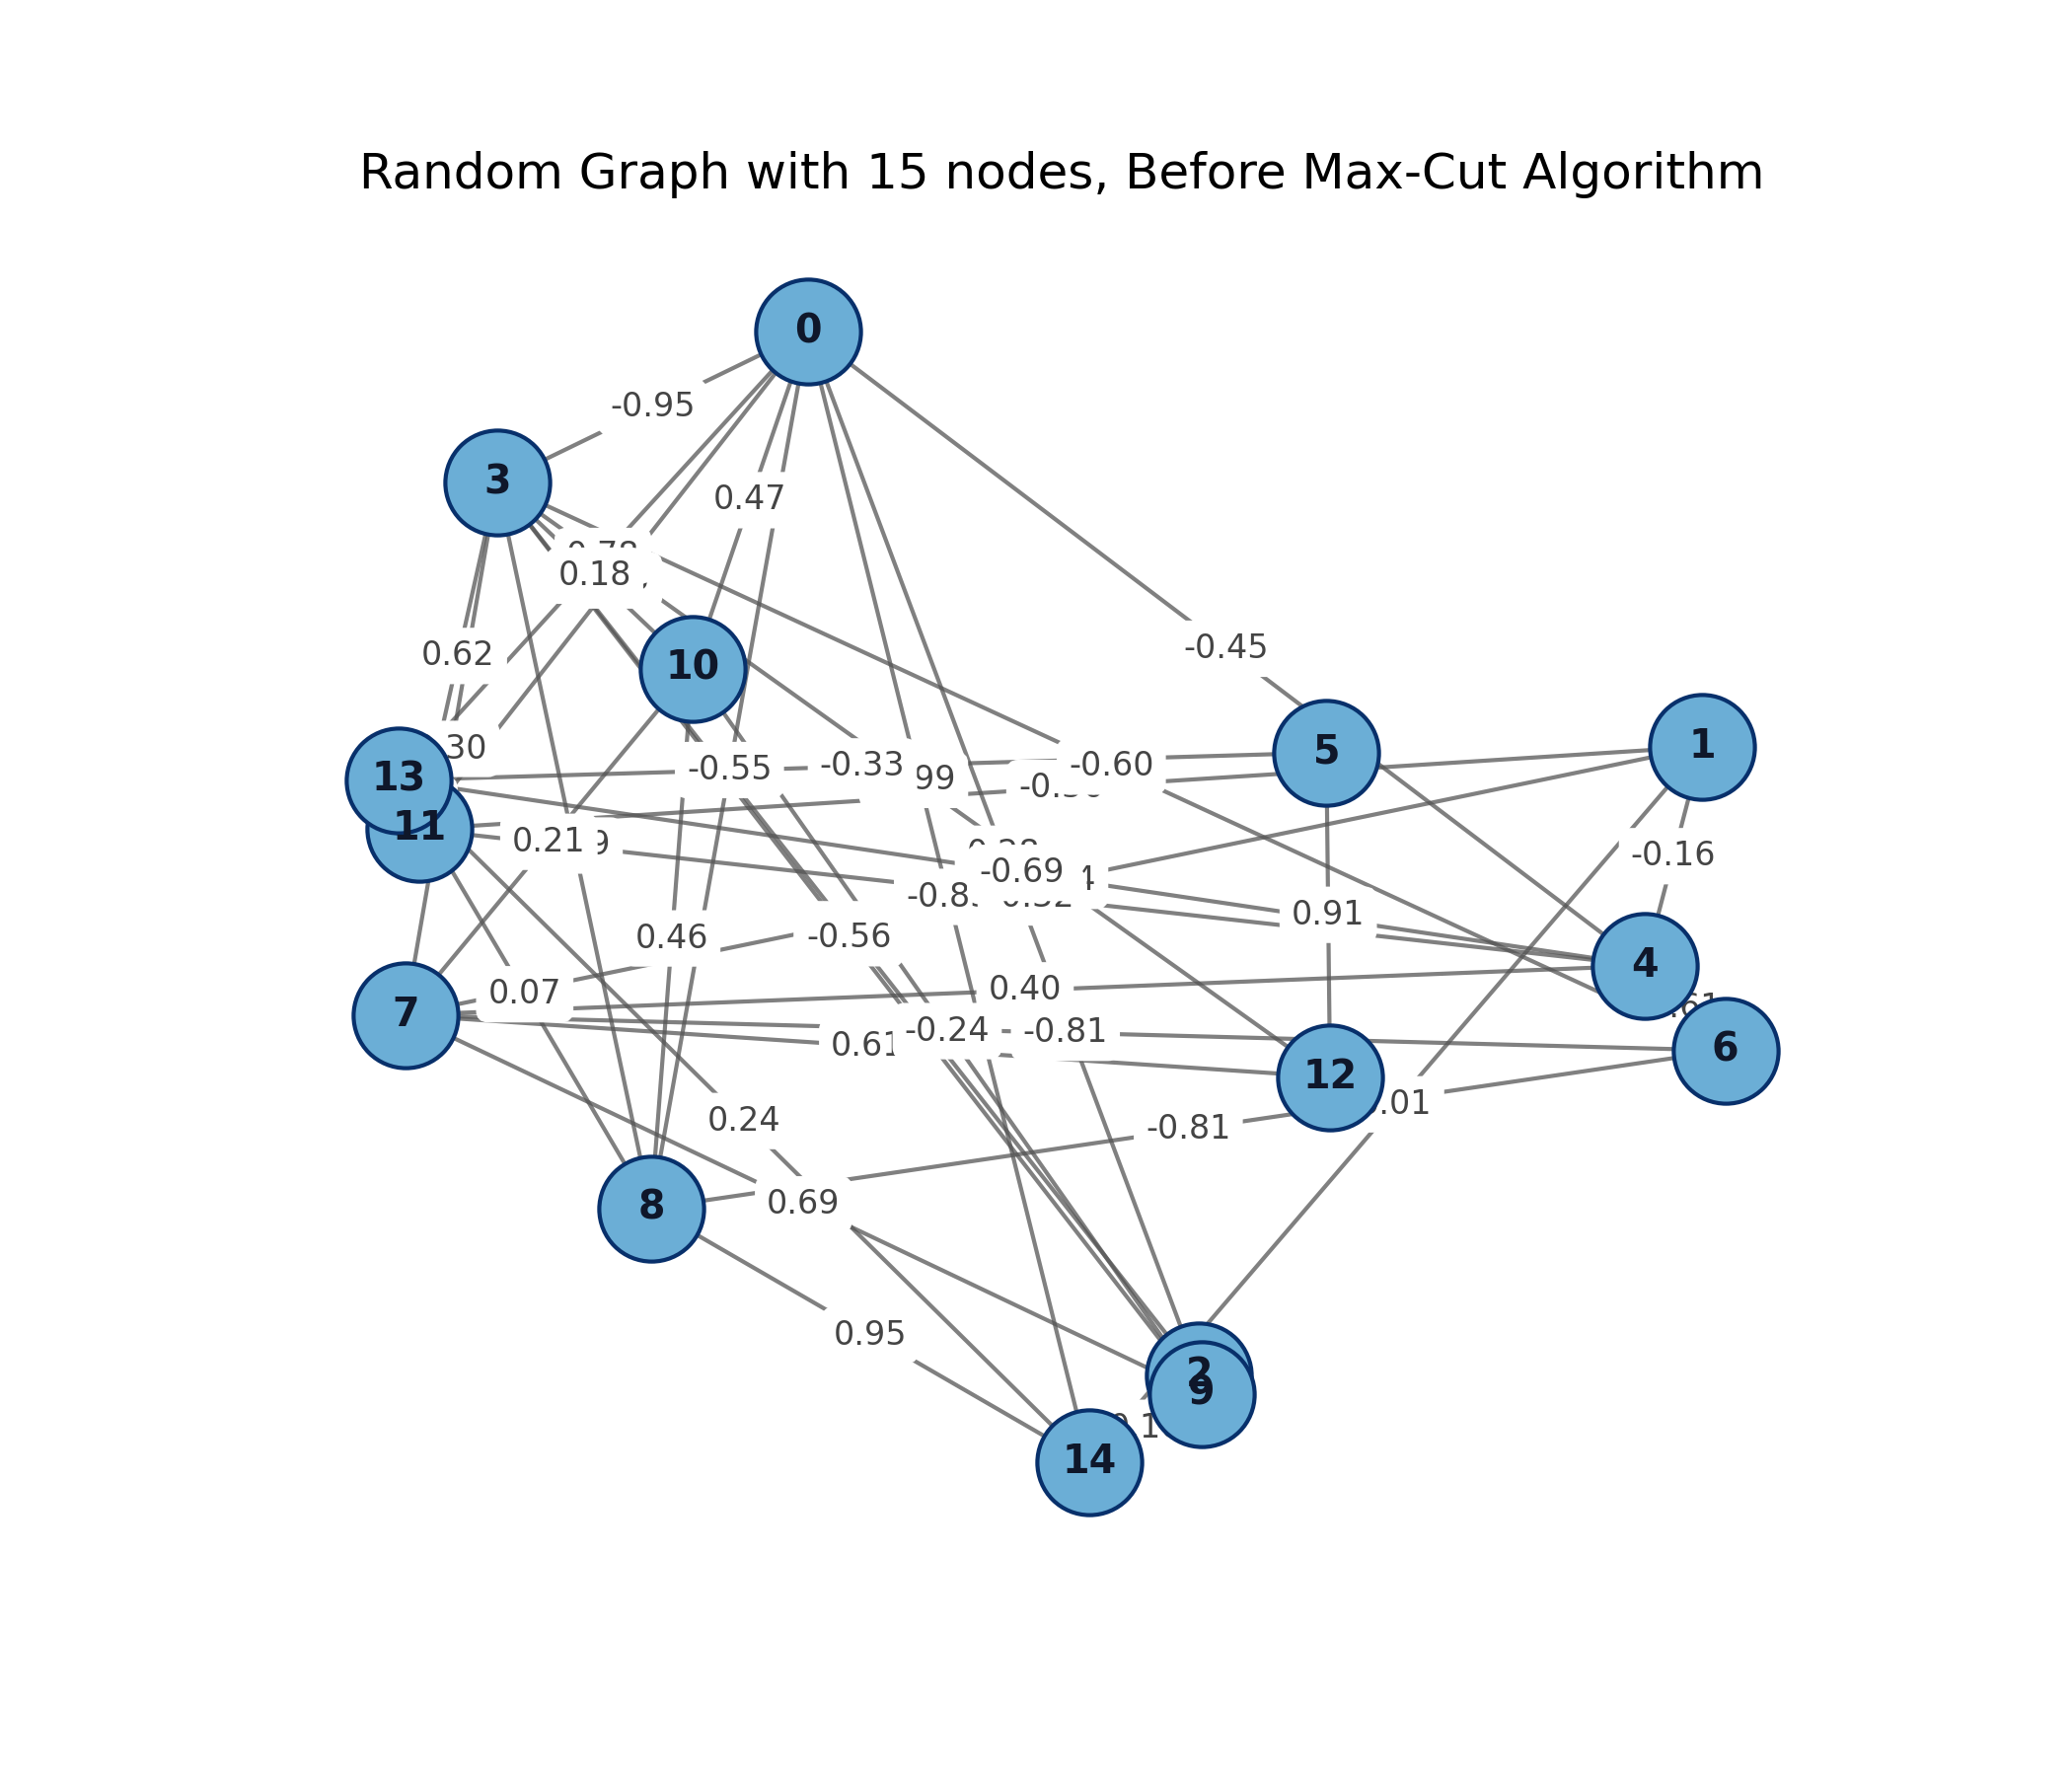

In [25]:
Image(filename='mi_grafo.png')

### Después de la optimización 

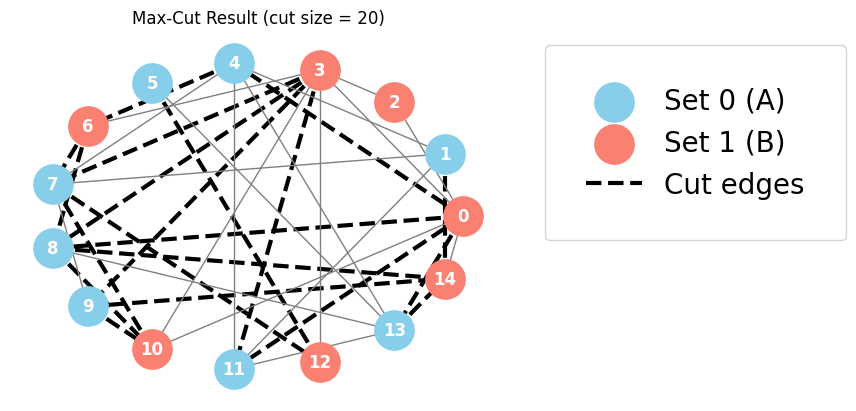

In [47]:
# ---- 6) Display the graph ----------------------------------------------------
G 
G.add_edges_from(G.edges)

# Partition nodes into two sets by the bit assignment
partition_0 = [i for i in G.nodes if x[i] == 0]
partition_1 = [i for i in G.nodes if x[i] == 1]

# Compute layout for plotting
pos = nx.circular_layout(G)

# Draw nodes by partition color
nx.draw_networkx_nodes(G, pos, nodelist=partition_0, node_color="skyblue", node_size=800, label="Set 0 (A)")
nx.draw_networkx_nodes(G, pos, nodelist=partition_1, node_color="salmon", node_size=800, label="Set 1 (B)")

# Draw edges: highlight cut edges
cut_edges = [(i, j) for i, j in G.edges if x[i] != x[j]]
uncut_edges = [(i, j) for i, j in G.edges if x[i] == x[j]]

nx.draw_networkx_edges(G, pos, edgelist=cut_edges, width=3, edge_color="black", style="dashed", label="Cut edges")
nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, width=1, edge_color="gray")

nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

plt.title(f"Max-Cut Result (cut size = {cut})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderpad=1.5, scatterpoints=1, fontsize=20)
#plt.legend(scatterpoints=1)
plt.axis("off")
plt.show()
